# 04 · Feature Engineering

[← Course home](../README.md)

Models only see the numbers we hand them. Feature engineering is the craft of turning raw columns into
numbers that make the learning problem *easy*.

**What you will learn**

- Why scaling matters for distance- and gradient-based models but not for trees
  (`StandardScaler`, `MinMaxScaler`, `RobustScaler`)
- How power transforms (log, Box-Cox, Yeo-Johnson) tame skewed distributions
- Encoding categoricals: one-hot, ordinal, unknown categories, and **target encoding** with
  cross-fitting to avoid leakage
- Binning, polynomial & interaction features (and the feature explosion they cause)
- Domain features and cyclical (sin/cos) encodings of time
- Packaging everything in `Pipeline` + `ColumnTransformer`, including custom transformers,
  `get_feature_names_out` and `set_output(transform="pandas")`

In [1]:
import time
from math import comb

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (FunctionTransformer, KBinsDiscretizer, MinMaxScaler,
                                   OneHotEncoder, OrdinalEncoder, PolynomialFeatures,
                                   PowerTransformer, RobustScaler, StandardScaler, TargetEncoder)
from sklearn.tree import DecisionTreeRegressor

from mlaz import PALETTE, load_mpg, load_titanic, savefig, set_style

set_style()
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option("display.precision", 3)

We use two datasets throughout:

- **Titanic** (891 passengers, binary target `survived`) — a mix of numeric and categorical columns with
  missing values.
- **Auto MPG** (398 cars, regression target `mpg`) — numeric columns on wildly different scales
  (weight in lb ≈ 2000–5000, acceleration in s ≈ 8–25).

We drop `alive` from Titanic immediately: it *is* the target in words (`yes`/`no`) — a textbook leak.

In [2]:
titanic = load_titanic().drop(columns=["alive"])
mpg = load_mpg().dropna(subset=["horsepower"]).reset_index(drop=True)
print(titanic.shape, mpg.shape)
mpg.describe().T[["mean", "std", "min", "max"]]

(891, 14) (392, 9)


,mean,std,min,max
mpg,23.446,7.805,9.0,46.6
cylinders,5.472,1.706,3.0,8.0
displacement,194.412,104.644,68.0,455.0
horsepower,104.469,38.491,46.0,230.0
weight,2977.584,849.403,1613.0,5140.0
acceleration,15.541,2.759,8.0,24.8
model_year,75.980,3.684,70.0,82.0


## 1 · Scaling

| Scaler | Formula | Output range | Robust to outliers? |
|---|---|---|---|
| `StandardScaler` | $z = (x-\mu)/\sigma$ | unbounded, mean 0, sd 1 | no ($\mu,\sigma$ are pulled by outliers) |
| `MinMaxScaler` | $x' = (x-\min)/(\max-\min)$ | $[0,1]$ | no (one outlier squashes everything else) |
| `RobustScaler` | $x' = (x-\text{median})/\text{IQR}$ | unbounded | yes (median and IQR ignore the tails) |

Titanic `fare` is a great stress test: heavily right-skewed with a few fares above £500.

In [3]:
fare = titanic[["fare"]]
scalers = {"Standard": StandardScaler(), "MinMax": MinMaxScaler(), "Robust": RobustScaler()}
scaled = {name: s.fit_transform(fare).ravel() for name, s in scalers.items()}
summary = pd.DataFrame({"raw": fare["fare"].to_numpy(), **scaled}).describe().T
summary[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
raw,3.220e+01,49.693,0.000,14.454,512.329
Standard,3.987e-18,1.001,-0.648,-0.357,9.667
MinMax,6.286e-02,0.097,0.000,0.028,1.000
Robust,7.687e-01,2.152,-0.626,0.000,21.563


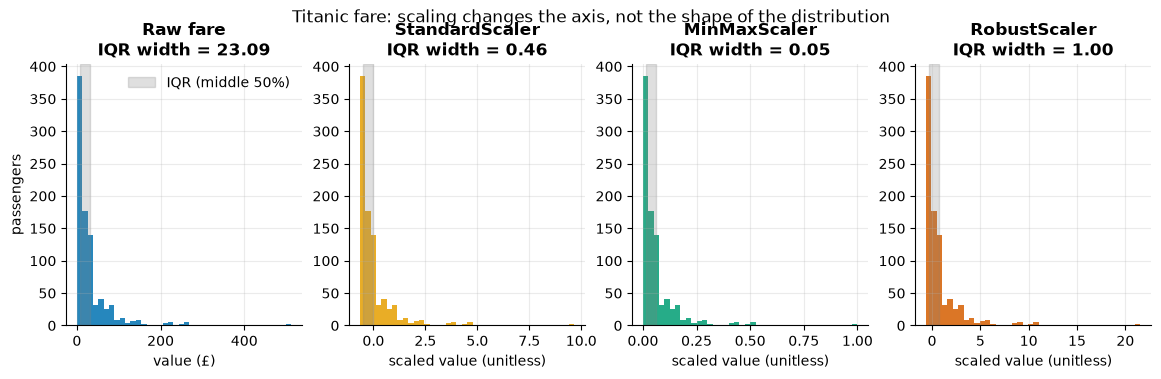

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, (name, values), color in zip(axes, [("Raw fare", fare["fare"].to_numpy()),
                                            *[(f"{k}Scaler", v) for k, v in scaled.items()]], PALETTE):
    ax.hist(values, bins=40, color=color, alpha=0.85)
    q1, med, q3 = np.percentile(values, [25, 50, 75])
    ax.axvspan(q1, q3, color="grey", alpha=0.25, label="IQR (middle 50%)")
    ax.set_title(f"{name}\nIQR width = {q3 - q1:.2f}")
    ax.set_xlabel("value (£)" if name == "Raw fare" else "scaled value (unitless)")
axes[0].set_ylabel("passengers")
axes[0].legend(loc="upper right")
fig.suptitle("Titanic fare: scaling changes the axis, not the shape of the distribution", y=1.04)
savefig("scaler_distributions")
plt.show()

Notice that **none of the scalers change the shape** — they are affine maps. MinMax squeezes the middle
50 % of passengers into a sliver near 0 because of the £512 outliers; RobustScaler keeps that middle
50 % at unit width. If you want to change the *shape*, you need a non-linear transform (section 2).

### Who cares about scale?

- **Distance-based** models (k-NN, k-means, SVM with RBF kernel): Euclidean distance
  $\sqrt{\sum_j (x_j - x'_j)^2}$ is dominated by the feature with the largest numeric range.
- **Gradient-descent** models (linear/logistic regression via SGD, neural nets): badly scaled features make
  the loss surface an elongated valley, so GD zig-zags.
- **Regularised** linear models (Ridge, Lasso): the penalty $\lambda\sum_j w_j^2$ treats every coefficient
  equally, which only makes sense if features are on comparable scales.
- **Tree-based** models: splits are thresholds $x_j \le t$, and any monotone rescaling keeps the same
  ordering → *identical* trees.

In [5]:
num_cols = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
X_mpg, y_mpg = mpg[num_cols], mpg["mpg"]
cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "k-NN (k=5)": KNeighborsRegressor(5),
    "Decision tree": DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
}
rows = []
for name, model in models.items():
    for scaling, est in [("raw", model), ("standardised", make_pipeline(StandardScaler(), model))]:
        r2 = cross_val_score(est, X_mpg, y_mpg, cv=cv, scoring="r2")
        rows.append({"model": name, "features": scaling, "CV R²": r2.mean(), "± sd": r2.std()})
scaling_results = pd.DataFrame(rows)
scaling_results

,model,features,CV R²,± sd
0,k-NN (k=5),raw,0.697,0.024
1,k-NN (k=5),standardised,0.854,0.024
2,Decision tree,raw,0.795,0.035
3,Decision tree,standardised,0.795,0.035


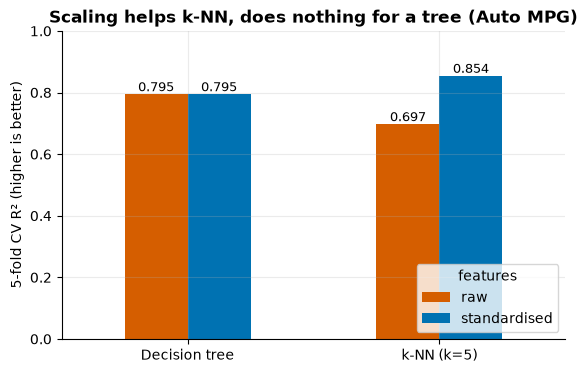

In [6]:
pivot = scaling_results.pivot(index="model", columns="features", values="CV R²")
ax = pivot.plot.bar(rot=0, color=[PALETTE[3], PALETTE[0]], figsize=(6.5, 4))
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("5-fold CV R² (higher is better)")
ax.set_xlabel("")
ax.set_title("Scaling helps k-NN, does nothing for a tree (Auto MPG)")
ax.legend(title="features", loc="lower right", frameon=True)
savefig("scaling_knn_vs_tree")
plt.show()

k-NN on raw features effectively computes distance on `weight` alone (range ~3500 lb vs ~16 s for
acceleration). After standardising, all six features get a vote. The tree's score is literally
unchanged: scaling is a monotone transform.

### Scaling and gradient descent

For least squares $L(\mathbf w) = \frac1n\lVert X\mathbf w - \mathbf y\rVert^2$ the Hessian is
$H = \frac2n X^\top X$. Gradient descent converges at a rate governed by the **condition number**
$\kappa(H) = \lambda_{\max}/\lambda_{\min}$: the learning rate must be below $2/\lambda_{\max}$ to stay
stable, but then progress along the $\lambda_{\min}$ direction is painfully slow.

In [7]:
Xc = X_mpg - X_mpg.mean()  # centred, unscaled
Xs = StandardScaler().fit_transform(X_mpg)
print(f"condition number of XᵀX, raw (centred) features: {np.linalg.cond(Xc.T @ Xc):,.0f}")
print(f"condition number of XᵀX, standardised features : {np.linalg.cond(Xs.T @ Xs):,.1f}")

condition number of XᵀX, raw (centred) features: 2,676,886
condition number of XᵀX, standardised features : 117.0


A 2-feature toy problem makes the geometry visible. Feature 1 has standard deviation 1, feature 2 has
standard deviation 5. We run 40 steps of gradient descent (largest stable-ish learning rate for each) from
the same start.

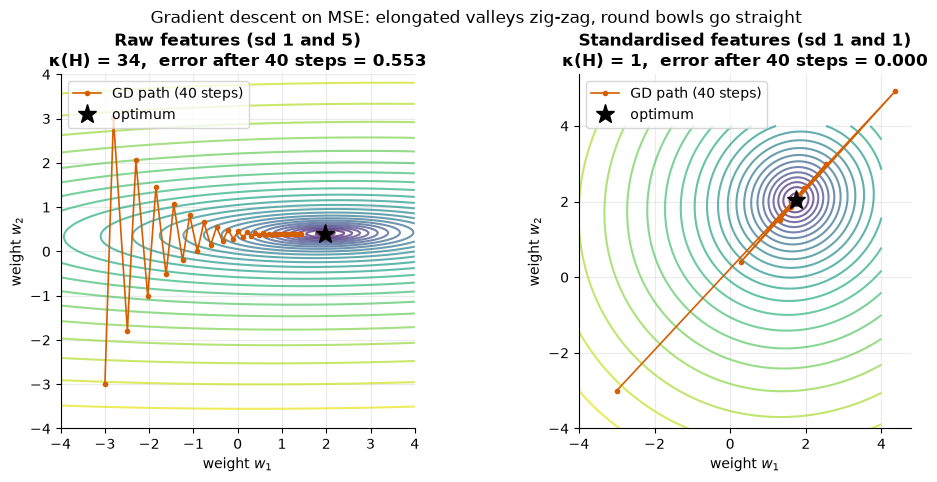

In [8]:
n = 200
X_toy = np.column_stack([rng.normal(0, 1, n), rng.normal(0, 5, n)])
w_true = np.array([2.0, 0.4])
y_toy = X_toy @ w_true + rng.normal(0, 0.5, n)


def gd_path(X, y, lr, steps=40, w0=(-3.0, -3.0)):
    w = np.array(w0, dtype=float)
    path = [w.copy()]
    for _ in range(steps):
        w -= lr * 2 / len(y) * X.T @ (X @ w - y)
        path.append(w.copy())
    return np.array(path)


def mse_grid(X, y, W1, W2):
    W = np.stack([W1.ravel(), W2.ravel()])
    return ((X @ W - y[:, None]) ** 2).mean(axis=0).reshape(W1.shape)


X_toy_s = X_toy / X_toy.std(axis=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, (X_, title) in zip(axes, [(X_toy, "Raw features (sd 1 and 5)"),
                                   (X_toy_s, "Standardised features (sd 1 and 1)")]):
    lam_max = np.linalg.eigvalsh(2 / n * X_.T @ X_).max()
    lr = 1.8 / lam_max
    path = gd_path(X_, y_toy, lr)
    w_opt = np.linalg.lstsq(X_, y_toy, rcond=None)[0]
    lo, hi = min(-4, w_opt.min() - 1), max(4, w_opt.max() + 1)
    W1, W2 = np.meshgrid(np.linspace(lo, hi, 200), np.linspace(lo, hi, 200))
    ax.contour(W1, W2, np.log(mse_grid(X_, y_toy, W1, W2)), levels=25, cmap="viridis", alpha=0.7)
    ax.plot(path[:, 0], path[:, 1], "o-", color=PALETTE[3], ms=3, lw=1.2, label="GD path (40 steps)")
    ax.plot(*w_opt, "*", color="black", ms=14, label="optimum")
    ax.set_title(f"{title}\nκ(H) = {np.linalg.cond(X_.T @ X_):.0f},  error after 40 steps = "
                 f"{np.linalg.norm(path[-1] - w_opt):.3f}")
    ax.set_xlabel("weight $w_1$")
    ax.set_ylabel("weight $w_2$")
    ax.set_aspect("equal")
    ax.legend(loc="upper left", frameon=True)
fig.suptitle("Gradient descent on MSE: elongated valleys zig-zag, round bowls go straight", y=1.02)
savefig("gd_scaling_contours")
plt.show()

> **Rule of thumb:** scale for k-NN, SVMs, PCA, k-means, regularised linear models and anything trained by
> gradient descent. Don't bother for trees and tree ensembles. Always **fit the scaler on the training
> data only** (a `Pipeline` does this for you inside cross-validation).

## 2 · Power transforms: changing the shape

Skewed features (incomes, prices, counts) have long right tails. Linear models are thrown off by them,
and even scaled, the bulk of the data lives in a tiny region. Options:

- **Log**: $x' = \log(1+x)$ — simple, needs $x > -1$.
- **Box-Cox** (strictly positive $x$):
  $x^{(\lambda)} = \dfrac{x^\lambda-1}{\lambda}$ for $\lambda\ne0$, $\log x$ for $\lambda=0$.
- **Yeo-Johnson**: a Box-Cox variant that also handles zero and negative values.

`PowerTransformer` picks $\lambda$ by maximum likelihood (the value that makes the data look most Gaussian)
and standardises the result by default. Fifteen Titanic passengers paid a fare of 0, so Box-Cox needs a shift.

In [9]:
f = titanic["fare"].to_numpy()
print("passengers with fare == 0:", (f == 0).sum())
bc = PowerTransformer(method="box-cox").fit(f[:, None] + 1)  # shift to make strictly positive
yj = PowerTransformer(method="yeo-johnson").fit(f[:, None])
transformed = {
    "raw fare": f,
    "log1p(fare)": np.log1p(f),
    f"Box-Cox(fare+1), λ={bc.lambdas_[0]:.2f}": bc.transform(f[:, None] + 1).ravel(),
    f"Yeo-Johnson, λ={yj.lambdas_[0]:.2f}": yj.transform(f[:, None]).ravel(),
}
pd.Series({k: stats.skew(v) for k, v in transformed.items()}, name="skewness").to_frame()

passengers with fare == 0: 15


,skewness
raw fare,4.779
log1p(fare),0.394
"Box-Cox(fare+1), λ=-0.10",-0.040
"Yeo-Johnson, λ=-0.10",-0.040


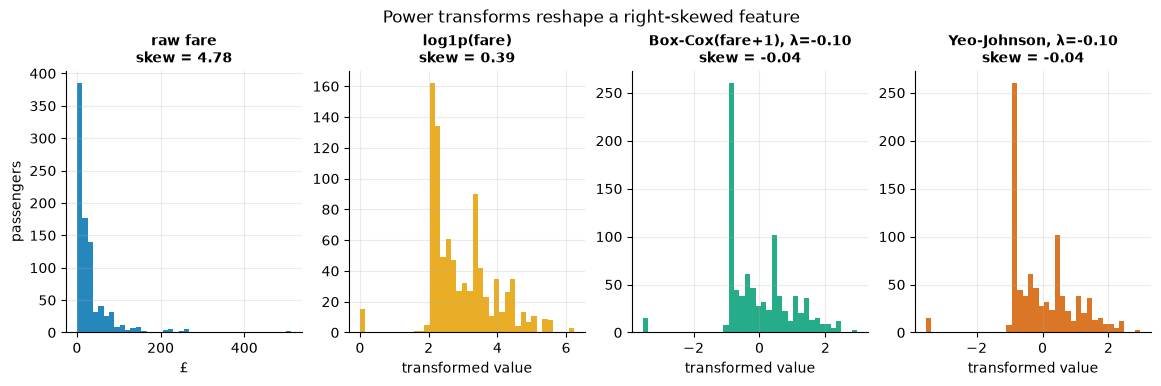

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, (name, v), color in zip(axes, transformed.items(), PALETTE):
    ax.hist(v, bins=40, color=color, alpha=0.85)
    ax.set_title(f"{name}\nskew = {stats.skew(v):.2f}", fontsize=10)
    ax.set_xlabel("£" if name == "raw fare" else "transformed value")
axes[0].set_ylabel("passengers")
fig.suptitle("Power transforms reshape a right-skewed feature", y=1.06)
savefig("power_transforms")
plt.show()

The spike on the left of the transformed plots is the 15 zero-fare passengers — no monotone transform can
spread a single repeated value. Power transforms matter most for **linear** models and distance-based
models; trees are, again, indifferent (log is monotone).

## 3 · Encoding categorical features

### One-hot and ordinal encoding

- **One-hot**: one binary column per category. No implied order. Right choice for nominal features
  (`embarked` ∈ {C, Q, S}) in linear models.
- **Ordinal**: map categories to integers $0,1,2,\dots$. Right for genuinely ordered categories
  (`class` ∈ {Third < Second < First}), and often fine for trees even on nominal data.

In [11]:
tr_df, te_df = train_test_split(titanic, test_size=0.25, random_state=RANDOM_STATE,
                                stratify=titanic["survived"])
ohe = OneHotEncoder(sparse_output=False).fit(tr_df[["embarked", "sex"]].fillna("missing"))
print(ohe.get_feature_names_out())
ohe.transform(pd.DataFrame({"embarked": ["S", "C"], "sex": ["female", "male"]}))

['embarked_C' 'embarked_Q' 'embarked_S' 'embarked_missing' 'sex_female'
 'sex_male']


array([[0., 0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 0., 1.]])

In [12]:
ord_enc = OrdinalEncoder(categories=[["Third", "Second", "First"]]).fit(tr_df[["class"]])
pd.DataFrame({"class": ["First", "Third", "Second"],
              "encoded": ord_enc.transform(pd.DataFrame({"class": ["First", "Third", "Second"]})).ravel()})

,class,encoded
0,First,2.0
1,Third,0.0
2,Second,1.0


Always pass `categories=` explicitly for ordinal features — the default is *alphabetical*
(First=0, Second=1, Third=2), which happens to be backwards here and would be meaningless for, e.g.,
`["low", "medium", "high"]`.

### Unknown and rare categories

Production data will contain categories you never saw in training. By default `OneHotEncoder` raises an
error. `handle_unknown="ignore"` encodes them as all zeros; `handle_unknown="infrequent_if_exist"` together
with `min_frequency` lumps rare categories (in training) and unseen ones (at prediction time) into a
shared `infrequent` column.

In [13]:
brands = mpg["name"].str.split().str[0]
print(f"{brands.nunique()} brands; rarest: {brands.value_counts().tail(5).to_dict()}")
enc_rare = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10, sparse_output=False)
enc_rare.fit(brands.to_frame("brand"))
print(len(enc_rare.get_feature_names_out()), "columns:", list(enc_rare.get_feature_names_out()))
new_cars = pd.DataFrame({"brand": ["ford", "tesla", "subaru"]})  # tesla unseen, subaru rare
pd.DataFrame(enc_rare.transform(new_cars), index=new_cars["brand"],
             columns=enc_rare.get_feature_names_out()).loc[:, lambda d: d.any()]

37 brands; rarest: {'capri': 1, 'mercedes': 1, 'vokswagen': 1, 'triumph': 1, 'nissan': 1}
15 columns: ['brand_amc', 'brand_buick', 'brand_chevrolet', 'brand_datsun', 'brand_dodge', 'brand_ford', 'brand_honda', 'brand_mazda', 'brand_mercury', 'brand_oldsmobile', 'brand_plymouth', 'brand_pontiac', 'brand_toyota', 'brand_volkswagen', 'brand_infrequent_sklearn']


,brand_ford,brand_infrequent_sklearn
brand,,
ford,1.0,0.0
tesla,0.0,1.0
subaru,0.0,1.0


In [14]:
try:
    OneHotEncoder().fit(brands.to_frame("brand")).transform(new_cars)
except ValueError as e:
    print("default handle_unknown='error' ->", str(e)[:90], "...")

default handle_unknown='error' -> Found unknown categories ['tesla'] in column 0 during transform ...


### Target encoding for high-cardinality features

One-hot on a feature with 1 000 levels creates 1 000 sparse columns. **Target encoding** replaces each
category $c$ with a (shrunk) mean of the target in that category:

$$
\text{enc}(c) = \frac{n_c\,\bar y_c + m\,\bar y}{n_c + m}
$$

where $n_c$ is the category count, $\bar y_c$ the category mean, $\bar y$ the global mean and $m$ a
smoothing strength (sklearn's `smooth="auto"` picks it with an empirical-Bayes estimate). Rare categories are
pulled toward the global mean.

**The danger — target leakage.** If you compute $\bar y_c$ on the same rows you then train on, each row's
own target leaks into its feature. For a category seen once, $\bar y_c$ *is* the row's target! The model
learns to trust the encoding blindly and collapses on new data.

**The fix — cross-fitting.** `TargetEncoder.fit_transform` splits the training set into $K$ folds and
encodes each fold using statistics from the *other* folds only. `transform` (used on test data) uses
statistics from the full training set.

Let's demonstrate with a deliberately useless feature: a random ID with 1 000 levels (about two training rows
per level), pure noise with respect to the target.

In [15]:
n = 3000
X_leak = pd.DataFrame({
    "informative": rng.normal(size=n),
    "noise_id": rng.integers(0, 1000, n).astype(str),  # ~2 train rows per level, no relation to y
})
y_leak = 2 * X_leak["informative"] + rng.normal(0, 1, n)
Xtr, Xte, ytr, yte = train_test_split(X_leak, y_leak, test_size=0.3, random_state=RANDOM_STATE)


def naive_target_encode(train_col, y_train, col):
    means = y_train.groupby(train_col).mean()
    return col.map(means).fillna(y_train.mean()).to_numpy()


results = {}
# (a) naive: encode train with train means computed on the same rows
Ztr = np.column_stack([Xtr["informative"], naive_target_encode(Xtr["noise_id"], ytr, Xtr["noise_id"])])
Zte = np.column_stack([Xte["informative"], naive_target_encode(Xtr["noise_id"], ytr, Xte["noise_id"])])
lr_naive = LinearRegression().fit(Ztr, ytr)
results["naive mean encoding"] = (lr_naive.score(Ztr, ytr), lr_naive.score(Zte, yte), lr_naive.coef_[1])

# (b) TargetEncoder with cross-fitting inside fit_transform
te = TargetEncoder(target_type="continuous", cv=KFold(5, shuffle=True, random_state=RANDOM_STATE))
Ztr = np.column_stack([Xtr["informative"], te.fit_transform(Xtr[["noise_id"]], ytr).ravel()])
Zte = np.column_stack([Xte["informative"], te.transform(Xte[["noise_id"]]).ravel()])
lr_cf = LinearRegression().fit(Ztr, ytr)
results["TargetEncoder (cross-fitted)"] = (lr_cf.score(Ztr, ytr), lr_cf.score(Zte, yte), lr_cf.coef_[1])

leak_df = pd.DataFrame(results, index=["train R²", "test R²", "coef on noise_id encoding"]).T
leak_df

,train R²,test R²,coef on noise_id encoding
naive mean encoding,0.824,0.746,0.286
TargetEncoder (cross-fitted),0.802,0.800,-0.004


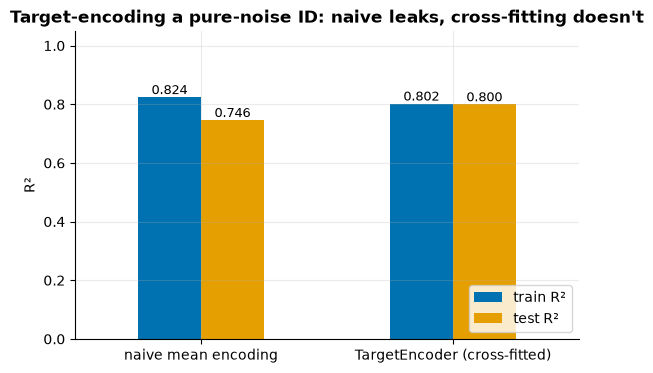

In [16]:
ax = leak_df[["train R²", "test R²"]].plot.bar(rot=0, color=[PALETTE[0], PALETTE[1]], figsize=(6.5, 4))
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("R²")
ax.set_xlabel("")
ax.set_title("Target-encoding a pure-noise ID: naive leaks, cross-fitting doesn't")
ax.legend(loc="lower right", frameon=True)
savefig("target_encoding_leakage")
plt.show()

The naive encoding makes the noise feature look useful (the model puts a sizeable coefficient on it),
inflating train R² and hurting test R². With cross-fitting the model
correctly assigns it almost zero weight, and train and test scores agree.

> **Gotcha:** `te.fit(X, y).transform(X)` is **not** the same as `te.fit_transform(X, y)` — only the latter
> cross-fits. Inside a `Pipeline`, sklearn calls `fit_transform` during training, so you are safe.

On real data: car **brand** in Auto MPG (37 levels) target-encoded vs one-hot for a Ridge model.

In [17]:
X_brand = mpg[num_cols].assign(brand=brands)
cat_sel = make_column_selector(dtype_include=object)
num_sel = make_column_selector(dtype_include=np.number)
for name, encoder in [
    ("no brand", "drop"),
    ("one-hot brand", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=5)),
    ("target-encoded brand", TargetEncoder(target_type="continuous",
                                           cv=KFold(5, shuffle=True, random_state=RANDOM_STATE))),
]:
    pre = ColumnTransformer([("num", StandardScaler(), num_sel), ("cat", encoder, cat_sel)])
    r2 = cross_val_score(make_pipeline(pre, Ridge(1.0)), X_brand, y_mpg, cv=cv, scoring="r2")
    print(f"{name:22s} CV R² = {r2.mean():.3f} ± {r2.std():.3f}")

no brand               CV R² = 0.801 ± 0.022
one-hot brand          CV R² = 0.808 ± 0.028
target-encoded brand   CV R² = 0.819 ± 0.016


Brand adds a little signal on top of the physical specs either way. Target encoding shines when the number
of levels is in the hundreds or thousands (zip codes, product IDs, user IDs).

## 4 · Binning (discretisation)

`KBinsDiscretizer` turns a continuous feature into $k$ intervals. It lets a *linear* model learn a
step-shaped, non-monotone effect (e.g. survival is high for children, lower for adults, and different again
for the elderly), at the cost of throwing away within-bin information.

- `strategy="uniform"`: equal-width bins
- `strategy="quantile"`: equal-count bins
- `strategy="kmeans"`: bins from 1-D k-means

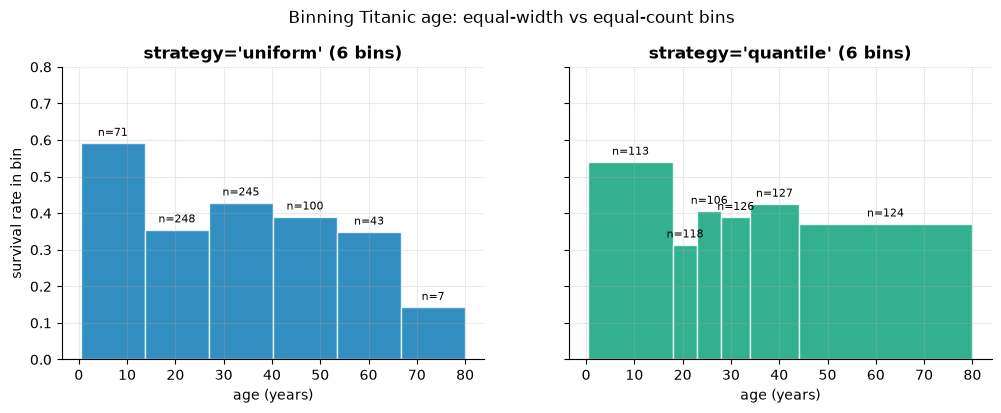

In [18]:
ages = titanic[["age", "survived"]].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, strategy, color in zip(axes, ["uniform", "quantile"], [PALETTE[0], PALETTE[2]]):
    kb = KBinsDiscretizer(n_bins=6, encode="ordinal", strategy=strategy).fit(ages[["age"]])
    edges = kb.bin_edges_[0]
    b = kb.transform(ages[["age"]]).ravel().astype(int)
    rate = ages.groupby(b)["survived"].mean()
    counts = np.bincount(b)
    ax.bar(edges[:-1], rate.to_numpy(), width=np.diff(edges), align="edge", color=color,
           alpha=0.8, edgecolor="white")
    for left, width, r, c in zip(edges[:-1], np.diff(edges), rate.to_numpy(), counts):
        ax.text(left + width / 2, r + 0.02, f"n={c}", ha="center", fontsize=8)
    ax.set_title(f"strategy='{strategy}' (6 bins)")
    ax.set_xlabel("age (years)")
    ax.set_ylim(0, 0.8)
axes[0].set_ylabel("survival rate in bin")
fig.suptitle("Binning Titanic age: equal-width vs equal-count bins", y=1.03)
savefig("binning_age")
plt.show()

Uniform bins can end up nearly empty in the tails (noisy estimates); quantile bins have equal support but
may be very wide where data are sparse. Binning is mostly useful for linear models — trees find their own
thresholds.

## 5 · Polynomial and interaction features

A linear model $\hat y = w_0 + w_1x$ can't fit a curve, but a linear model in the *expanded* features
$[1, x, x^2, x^3]$ can — it is still linear in the weights, so all the linear-model machinery still works.
With several inputs, `PolynomialFeatures` also creates **interactions** such as $x_1x_2$.

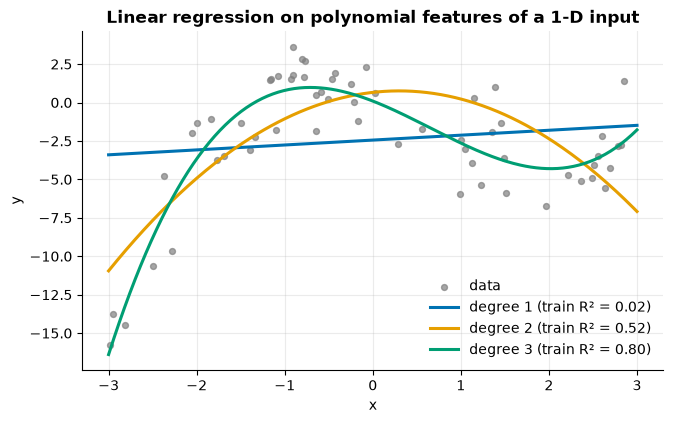

In [19]:
x = np.sort(rng.uniform(-3, 3, 60))
y = 0.5 * x**3 - x**2 - 2 * x + rng.normal(0, 2, x.size)
xx = np.linspace(-3, 3, 300)[:, None]
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.scatter(x, y, s=18, color="grey", alpha=0.7, label="data")
for degree, color in zip([1, 2, 3], PALETTE):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression()).fit(x[:, None], y)
    r2 = model.score(x[:, None], y)
    ax.plot(xx, model.predict(xx), color=color, lw=2.2, label=f"degree {degree} (train R² = {r2:.2f})")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Linear regression on polynomial features of a 1-D input")
ax.legend()
savefig("polynomial_features_fit")
plt.show()

In [20]:
pf = PolynomialFeatures(degree=2).fit(pd.DataFrame({"weight": [1.0], "horsepower": [1.0]}))
print(pf.get_feature_names_out())

['1' 'weight' 'horsepower' 'weight^2' 'weight horsepower' 'horsepower^2']


### The feature explosion

With $d$ input features and degree $k$, `PolynomialFeatures` produces every monomial of total degree
$\le k$:

$$ \#\text{features} = \binom{d+k}{k} $$

(including the bias column). This grows like $d^k$ — quickly more columns than rows.

In [21]:
ds = [2, 5, 10, 20, 50]
ks = [1, 2, 3, 4, 5]
explosion = pd.DataFrame({f"degree {k}": [comb(d + k, k) for d in ds] for k in ks},
                         index=pd.Index(ds, name="input features d"))
# sanity-check the formula against sklearn for one cell
assert PolynomialFeatures(3).fit(np.zeros((1, 10))).n_output_features_ == explosion.loc[10, "degree 3"]
explosion

,degree 1,degree 2,degree 3,degree 4,degree 5
input features d,,,,,
2,3,6,10,15,21
5,6,21,56,126,252
10,11,66,286,1001,3003
20,21,231,1771,10626,53130
50,51,1326,23426,316251,3478761


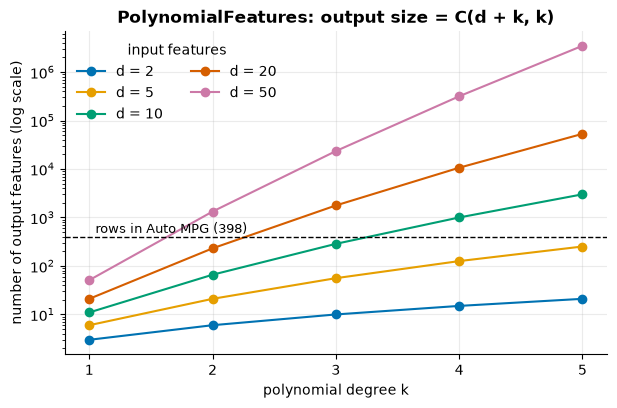

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for d, color in zip(ds, PALETTE):
    ax.plot(ks, [comb(d + k, k) for k in ks], "o-", color=color, label=f"d = {d}")
ax.axhline(398, color="black", ls="--", lw=1)
ax.text(1.05, 480, "rows in Auto MPG (398)", fontsize=9)
ax.set_yscale("log")
ax.set_xticks(ks)
ax.set_xlabel("polynomial degree k")
ax.set_ylabel("number of output features (log scale)")
ax.set_title("PolynomialFeatures: output size = C(d + k, k)")
ax.legend(title="input features", ncol=2)
savefig("feature_explosion")
plt.show()

Use `interaction_only=True` to keep only cross-products, keep the degree low (2 is usually plenty), and pair
polynomial features with regularisation (Ridge/Lasso, chapter 05).

## 6 · Domain features

Often the best feature is one a domain expert would write down. Physics says fuel consumption is driven by
how much mass the engine must move, so **power-to-weight** and **displacement per cylinder** are natural
candidates. Let's check whether they help a simple linear model on Auto MPG. We model $\log(\text{mpg})$
since fuel *consumption* (1/mpg) is closer to linear in the physics.

In [23]:
def add_domain_features(df):
    out = df.copy()
    out["power_to_weight"] = out["horsepower"] / out["weight"]       # hp per lb
    out["disp_per_cyl"] = out["displacement"] / out["cylinders"]     # cubic inches per cylinder
    return out


base = make_pipeline(StandardScaler(), LinearRegression())
log_y = np.log(y_mpg)
for name, X_ in [("raw specs", X_mpg), ("raw + domain features", add_domain_features(X_mpg))]:
    r2 = cross_val_score(base, X_, log_y, cv=cv, scoring="r2")
    print(f"{name:24s} CV R² on log(mpg) = {r2.mean():.3f} ± {r2.std():.3f}")

raw specs                CV R² on log(mpg) = 0.867 ± 0.016
raw + domain features    CV R² on log(mpg) = 0.881 ± 0.012


A modest gain from two lines of code — and the new features are *interpretable*. Domain features are
typically worth more than any amount of generic feature generation.

## 7 · Dates, times and cyclical features

From a timestamp you can extract `year`, `month`, `dayofweek`, `hour`, `is_weekend`, "days since X", etc.
(`df["ts"].dt.hour` and friends). Periodic quantities have a catch: hour 23 and hour 0 are neighbours, but
as integers they are 23 apart. Encode them on a circle:

$$ \text{hour}_{\sin} = \sin\!\left(\frac{2\pi\,\text{hour}}{24}\right),\qquad
   \text{hour}_{\cos} = \cos\!\left(\frac{2\pi\,\text{hour}}{24}\right) $$

In [24]:
ts = pd.Series(pd.date_range("2024-01-01", periods=48, freq="h"))
dt_feats = pd.DataFrame({"timestamp": ts, "hour": ts.dt.hour, "dayofweek": ts.dt.dayofweek,
                         "is_weekend": ts.dt.dayofweek >= 5})
dt_feats["hour_sin"] = np.sin(2 * np.pi * dt_feats["hour"] / 24)
dt_feats["hour_cos"] = np.cos(2 * np.pi * dt_feats["hour"] / 24)
dt_feats.iloc[[0, 6, 12, 18, 23]]

,timestamp,hour,dayofweek,is_weekend,hour_sin,hour_cos
0,2024-01-01 00:00:00,0,0,False,0.000e+00,1.000e+00
6,2024-01-01 06:00:00,6,0,False,1.000e+00,6.123e-17
12,2024-01-01 12:00:00,12,0,False,1.225e-16,-1.000e+00
18,2024-01-01 18:00:00,18,0,False,-1.000e+00,-1.837e-16
23,2024-01-01 23:00:00,23,0,False,-2.588e-01,9.659e-01


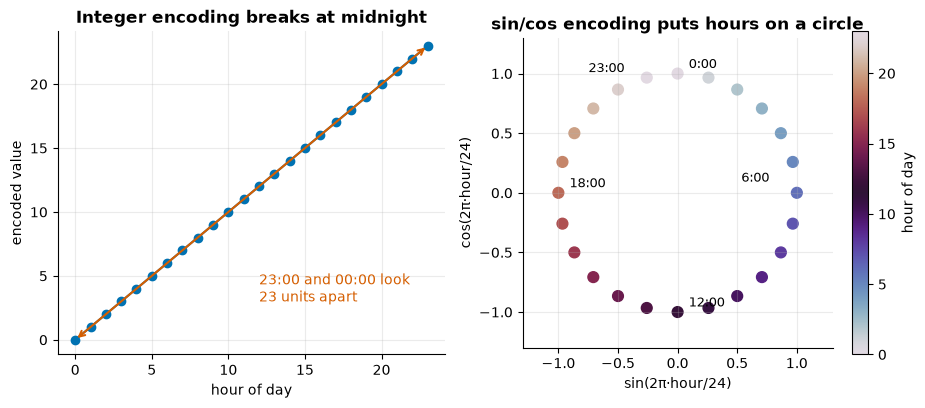

In [25]:
def cyclical(period):
    return FunctionTransformer(lambda X: np.column_stack([np.sin(2 * np.pi * X / period),
                                                          np.cos(2 * np.pi * X / period)]))


hours = np.arange(24)
enc = cyclical(24).fit_transform(hours[:, None])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(hours, hours, "o-", color=PALETTE[0])
axes[0].annotate("", xy=(23, 23), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="<->", color=PALETTE[3], lw=1.5))
axes[0].text(12, 3, "23:00 and 00:00 look\n23 units apart", color=PALETTE[3])
axes[0].set_xlabel("hour of day")
axes[0].set_ylabel("encoded value")
axes[0].set_title("Integer encoding breaks at midnight")
sc = axes[1].scatter(enc[:, 0], enc[:, 1], c=hours, cmap="twilight", s=60)
for h, off in [(0, (8, 4)), (6, (-40, 8)), (12, (8, 4)), (18, (8, 4)), (23, (-42, 4))]:
    axes[1].annotate(f"{h}:00", enc[h], textcoords="offset points", xytext=off, fontsize=9)
axes[1].set_xlim(-1.3, 1.3)
axes[1].set_ylim(-1.3, 1.3)
axes[1].set_aspect("equal")
axes[1].set_xlabel("sin(2π·hour/24)")
axes[1].set_ylabel("cos(2π·hour/24)")
axes[1].set_title("sin/cos encoding puts hours on a circle")
fig.colorbar(sc, ax=axes[1], label="hour of day")
savefig("cyclical_encoding")
plt.show()

Always use **both** sin and cos: sin alone maps 3:00 and 9:00 to the same value
($\sin(\pi/4)=\sin(3\pi/4)$). The pair is unique for every hour. (Tree models are often fine with the raw integer;
sklearn's `SplineTransformer(extrapolation="periodic")` is a smoother alternative for linear models.)

## 8 · Pipelines: putting it all together

Doing all of the above by hand invites two bugs: forgetting a step at prediction time, and **leaking** test
statistics into preprocessing. A `Pipeline` chains steps so that `fit` fits each transformer on the
training data only, and `predict` replays the same fitted steps. `ColumnTransformer` routes different
columns to different sub-pipelines, and `make_column_selector` picks columns by dtype or regex so the
pipeline adapts to the dataframe.

We'll build a Titanic survival model with:

1. a **custom transformer class** that adds `family_size = sibsp + parch + 1` and `is_alone`,
2. numeric columns → median imputation → `log1p` via `FunctionTransformer` for fare → standardisation,
3. categorical columns → most-frequent imputation → one-hot encoding,
4. logistic regression.

In [26]:
class FamilyFeatures(BaseEstimator, TransformerMixin):
    """Add family_size = sibsp + parch + 1 and is_alone (a stateless custom transformer)."""

    def __init__(self, add_is_alone=True):
        self.add_is_alone = add_is_alone  # hyper-parameters are stored untouched in __init__

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        return self  # nothing to learn

    def transform(self, X):
        X = X.copy()
        X["family_size"] = X["sibsp"] + X["parch"] + 1
        if self.add_is_alone:
            X["is_alone"] = (X["family_size"] == 1).astype(int)
        return X

    def get_feature_names_out(self, input_features=None):
        extra = ["family_size"] + (["is_alone"] if self.add_is_alone else [])
        return np.asarray(list(self.feature_names_in_) + extra, dtype=object)


features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X_t = titanic[features].astype({"pclass": "category"})  # treat class as categorical
y_t = titanic["survived"]
X_tr, X_te, y_tr, y_te = train_test_split(X_t, y_t, test_size=0.25, random_state=RANDOM_STATE, stratify=y_t)

log_fare = FunctionTransformer(np.log1p, feature_names_out="one-to-one")
numeric = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
preprocess = ColumnTransformer([
    ("fare", make_pipeline(log_fare, StandardScaler()), ["fare"]),
    ("num", numeric, make_column_selector(pattern="^(?!fare$)", dtype_include=np.number)),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     make_column_selector(dtype_include=["object", "category"])),
])
clf = Pipeline([
    ("family", FamilyFeatures()),
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000)),
])
clf.fit(X_tr, y_tr)
print(f"test accuracy: {clf.score(X_te, y_te):.3f}")
cv_acc = cross_val_score(clf, X_t, y_t, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE))
print(f"5-fold CV accuracy: {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")

test accuracy: 0.785


5-fold CV accuracy: 0.798 ± 0.011


`get_feature_names_out` traces names through every step — invaluable for reading coefficients:

In [27]:
names = clf[:-1].get_feature_names_out()
coefs = pd.Series(clf.named_steps["model"].coef_.ravel(), index=names).sort_values()
coefs.to_frame("logistic coefficient")

,logistic coefficient
cat__sex_male,-1.223
cat__pclass_3,-0.842
num__age,-0.519
num__sibsp,-0.317
cat__embarked_S,-0.261
num__family_size,-0.237
num__is_alone,-0.220
num__parch,-0.052
cat__embarked_C,-0.020
cat__pclass_2,0.073


`set_output(transform="pandas")` makes every transformer return a DataFrame with those names, which is much
nicer for debugging a pipeline step by step:

In [28]:
clf.set_output(transform="pandas")
clf.fit(X_tr, y_tr)
clf[:-1].transform(X_te).head()

,fare__fare,num__age,num__sibsp,num__parch,num__family_size,num__is_alone,cat__pclass_1,cat__pclass_2,cat__pclass_3,cat__sex_female,cat__sex_male,cat__embarked_C,cat__embarked_Q,cat__embarked_S
157,-0.753,0.019,-0.465,-0.451,-0.553,0.781,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
501,-0.788,-0.675,-0.465,-0.451,-0.553,0.781,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
352,-0.851,-1.139,0.537,0.750,0.764,-1.281,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
82,-0.783,-0.058,-0.465,-0.451,-0.553,0.781,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
683,0.961,-1.216,4.542,1.952,4.057,-1.281,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


Because every hyper-parameter is reachable with the `step__substep__param` syntax, the whole pipeline can be
tuned by grid search without leakage (chapter 09):

In [29]:
sorted(k for k in clf.get_params() if k.startswith("preprocess__cat__onehot__"))[:4]

['preprocess__cat__onehot__categories',
 'preprocess__cat__onehot__drop',
 'preprocess__cat__onehot__dtype',
 'preprocess__cat__onehot__feature_name_combiner']

The HTML diagram that Jupyter shows for `clf` doesn't render on GitHub, so the README draws the same
structure as a Mermaid diagram. Here is a compact text version, including which columns each
`make_column_selector` actually picked at fit time:

In [30]:
print("Pipeline:", " -> ".join(clf.named_steps))
for name, trans, cols in clf.named_steps["preprocess"].transformers_:
    steps = [s for s, _ in trans.steps] if hasattr(trans, "steps") else [type(trans).__name__]
    print(f"  {name:5s} {' -> '.join(steps):35s} columns={list(cols)}")

Pipeline: family -> preprocess -> model
  fare  functiontransformer -> standardscaler columns=['fare']
  num   impute -> scale                     columns=['age', 'sibsp', 'parch', 'family_size', 'is_alone']
  cat   impute -> onehot                    columns=['pclass', 'sex', 'embarked']


## Key takeaways

- Scaling is an **affine** change of units: essential for k-NN, SVMs, regularised and gradient-trained
  models; irrelevant for trees. `RobustScaler` resists outliers.
- Power transforms (log, Box-Cox, Yeo-Johnson) change the **shape** of skewed distributions.
- One-hot for nominal, ordinal (with explicit order) for ordered categories; plan for unseen and rare levels
  with `handle_unknown` / `min_frequency`.
- Target encoding compresses high-cardinality features but leaks unless **cross-fitted** —
  `TargetEncoder.fit_transform` does this for you.
- Polynomial features make linear models non-linear, but the column count grows as $\binom{d+k}{k}$.
- Domain features are often the biggest win; periodic features need sin/cos.
- Put everything in a `Pipeline` + `ColumnTransformer` so preprocessing is fitted on training folds only.

## Exercises

1. **Scaling and k.** Repeat the k-NN experiment with `MinMaxScaler` and `RobustScaler`. Which wins on Auto
   MPG? *Hint: wrap each scaler in `make_pipeline(scaler, KNeighborsRegressor(5))`.*
2. **Leak it on purpose.** Replace `te.fit_transform(Xtr, ytr)` with `te.fit(Xtr, ytr).transform(Xtr)` in the
   leakage demo. What happens to the train/test R² gap? *Hint: that path skips cross-fitting.*
3. **Interactions for Titanic.** Add `PolynomialFeatures(2, interaction_only=True)` after the one-hot step
   so the model can learn `sex × pclass`. Does CV accuracy improve? *Hint: insert it into the pipeline and
   check the new `get_feature_names_out()`.*
4. **Your own transformer.** For Auto MPG, write a class that adds `power_to_weight` and `disp_per_cyl`
   and has a `fit` that learns nothing. Use it in a pipeline with `cross_val_score`.
   *Hint: follow the `FamilyFeatures` template, including `get_feature_names_out`.*
5. **Cyclical months.** Encode `month` (1–12) with sin/cos. Which two months should end up closest to
   December? *Hint: compute Euclidean distances between the encoded points.*